## **Operational Flood Inundation Mapping (FIM) in United States**
In the United States, the National Oceanic and Atmospheric Administration-Office of Water Prediction (NOAA-OWP) utilizes the National Water Model (NWM) for operational hydrological forecasting. Its Flood Inundation Mapping (FIM) framework translates NWM discharge to inundation extent using the Height Above the Nearest Drainage (HAND) approach. The simplicity of the OWP HAND-FIM framework enables rapid, large-scale FIM predictions across the U.S., fostering a growing user and developer community beyond NOAA (Baruah et al.,2025). We have developed the OWP HAND-FIM ‘as a service’ (FIMserv), an open-source Python toolset for running the FIM generation procedures using NWM operational input data.By replicating Docker’s role in environment configuration in a simplified manner, this method bypasses containerization while maintaining a consistent and portable setup. The script dynamically adjusts to the local system’s structure, ensuring dependencies and file paths are properly aligned for successful execution (https://github.com/sdmlua/FIMserv).

### **Flood Inundation Mapping (FIM) Enhancement Using Surrogate Modeling**

##### The **Surrogate Modeling (SM)** is a U-Net convolutional architecture that leverages the binary FIMs generated from **NOAA Office of Water Prediction Height Above Nearest Drainage (NOAA OWP HAND)** as the **low-fidelity baseline**, and integrates additional **topographic and hydrologic forcings** to enhance accuracy and improve agreement with higher-fidelity inundation products.
---

### **Detailed Methodology**
For model training and validation across United States, the preprint is available here.

Supath Dhital, Sagy Cohen, Parvaneh Nikrou, et al. *Enhancement of low-fidelity flood inundation mapping through surrogate modeling.* **ESS Open Archive**, November 03, 2025.  
DOI: **[10.22541/essoar.176218121.12875584/v1](https://doi.org/10.22541/essoar.176218121.12875584/v1)** (Under review in WRR)

##### In this workshop, we will demonstrate-
1) Setting up and running FIMserv in one case study using Google Colab.
2) Visualization of the National Water Model streamflow for the specific event.
3) Generating the binary flood maps using the NWM streamflow.
4) Running the surrogate model and visualize the enhanced binary FIM.

---
### **Prerequisite**

1) A valid Google account

### **Implementation Note**

For demonstration purposes, we precomputed selected **HUC8-level static forcings** and host them in an **AWS S3** bucket for retrieval during processing. The framework is not limited to this setup: it can be deployed with custom datasets, or the trained SM can be transferred and fine-tuned using local high-resolution data to further improve accuracy.


![Operational Enhanced FIM workflow](https://raw.githubusercontent.com/sdmlua/FIMserv/main/src/fimserve/enhancement_withSM/graphics/operationalFIM.jpg)

Fig: The detailed methodology how this framework works within US.

**!! We are going to use the GPU later so- turn the runtime into GPU. Runtime--> Change runtime type --> T4 GPU**

### Install the **FIMserv framework** with PyPI using pip
This install all the require dependencies and modules for the low-fidelity flood inundation maps generation and enhancement using SM.

In [ ]:
!pip install uv
!uv pip install "fimserve[sm]==0.1.97"  #The [sm] version of fimserve will install extra dependencies need to run the deep learning based SM to enhance FIM

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 46.2 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 297 packages in 12.61s
Prepared 68 packages in 33.49s
Uninstalled 12 packages in 212ms
Installed 69 packages in 843ms
 + aiobotocore==2.26.0
 + aioitertools==0.13.0
 + apache-sedona==1.9.0
 + appdirs==1.4.4
 + arch==7.2.0
 + asciitree==0.3.3
 + async-lru==2.3.0
 + awscli==1.43.5
 + baseflow==0.1.0
 + boto3==1.41.5
 + botocore==1.41.5
 + cftime==1.6.5
 + color-operations==0.2.0
 + colorama==0.4.6
 + colour==0.1.5
 - dask==2026.1.1
 + dask==2025.12.0
 + dataretrieval==1.1.4
 + deprecated==1.3.1
 - docutils==0.21.2
 + docutils==0.19
 + fasteners==0.20
 + fimeval==0.1.64
 + fimserve==0.1.97
 - geemap==0.37.2
 + geemap==0.35.3
 + geocube==0.7.1
 + ipytree==0.2.2
 + jedi==0.20.0
 + jmespath==1.1.0
 + json5==0.14.0
 + jupyter==1.1.1
 + jupyter-loopback==0.3.3
 + jupyter-lsp==2.3.1
 + jupyterlab==4.5.7
 + jupyterlab-server==2.28.0
 + kaleido==0.2.1
 + kerchunk==0.2.

In [ ]:
import fimserve as fm

### Initialize the event and location [HUC8]
At this moment based on the HUC8, it retrieves all the static topographic forcings from AWS s3 bucket. And based on event date of flood, it will generate FIM based on NOAA OWP HAND framework- called as Low-Fidelity FIM here. Which further goes for the enhancement.

In [ ]:
huc_id = '03020201'
start_date = '2016-09-15'
end_date = '2016-10-25'

### Get the HUC8 data and retrospective discharge data

---



In [ ]:
#Download the HUC8 data
fm.DownloadHUC8('03020201')

Repository cloned into: /content/code/inundation-mapping (version: main)
Data for HUC 03020201 downloaded to /content/output/flood_03020201/03020201
Copied /content/output/flood_03020201/03020201/branch_ids.csv to /content/output/flood_03020201/fim_inputs.csv as fim_inputs.csv.
Unique feature IDs saved to /content/output/flood_03020201/feature_IDs.csv.


In [ ]:
#Get the NWM discharge data to see the hydrograph
fm.getNWMretrospectivedata(huc_id, start_date, end_date)
fm.plotNWMStreamflow(huc_id, start_date, end_date)

NWM discharge data saved to /content/output/flood_03020201/discharge/nwm30_retrospective.
*****No feature_id provided. Using the feature with max discharge: 11239411******
Static plot saved to: /content/output/flood_03020201/Plots/NWMStreamflow_11239411.png


In [ ]:
#Get the NWM discharge data for exact timestep
value_times = ['2016-10-10 22:00:00', '2016-10-14 15:00:00']
fm.getNWMretrospectivedata(huc_id, value_times=value_times)

NWM discharge data saved to /content/output/flood_03020201/discharge/nwm30_retrospective.
Discharge values saved to /content/data/inputs/NWM_20161010220000_03020201.csv
NWM discharge data saved to /content/output/flood_03020201/discharge/nwm30_retrospective.
Discharge values saved to /content/data/inputs/NWM_20161014150000_03020201.csv


In [ ]:
#Generate the FIM
fm.runOWPHANDFIM(huc_id)

Completed in 0.66 minutes.

Inundation mapping for 03020201 completed successfully.
Completed in 0.63 minutes.

Inundation mapping for 03020201 completed successfully.


In [ ]:
#This will download and save a sample test boundary smaller than HUC8- falls within huc_id
!mkdir -p clippingboundary
!wget -q --show-progress -O clippingboundary/subset_huc03020201.gpkg \
  https://raw.githubusercontent.com/sdmlua/ciroh-devcon26/main/surrogate-modeling/clip_boundary/subset_huc03020201.gpkg


clippingboundary/su 100%[===================>] 148.00K  --.-KB/s    in 0.02s   


In [ ]:
#Once this boundary is downloaded, initialize it
test_boundary = "/content/clippingboundary/subset_huc03020201.gpkg"

### Prepare the forcings

In [ ]:
fm.prepare_FORCINGs(
        huc_id=huc_id,
        event_date=value_times,
        data='retrospective',
        # forecast_range=None, #For the forecasting Flood Inundation Mapping enhanceent [supports shortrange [18 lead hours], mediumrange [7 days], longrange [30 days]]
        # forecast_date=None,  #If forecast_range is provided, forecast_date is required
        # sort_by=None    #For Medium and Long range forecast, to get the streamflow data, sort_by can be 'maximum', 'minimum', 'median']
        clip_boundary=test_boundary #This will clip all the forcings based on this boundary if it overlaps with given huc8 forcings
        )
print("FORCING data preparation completed.")


Forcings downloaded successfully.

Boundary provided. Checking overlap with all forcings...

All forcing rasters clipped successfully.

FIM already exists for 2016-10-10 22:00:00 — reusing NWM_20161010220000_03020201_inundation.tif

FIM already exists for 2016-10-14 15:00:00 — reusing NWM_20161014150000_03020201_inundation.tif

All requested FIM files already exist — skipping generation.

Preprocessing the FIM files...

  Grid 0: Paginated to offset 1000...
PWB Extraction complete.
  Grid 0: Paginated to offset 1000...
PWB Extraction complete.
FIM file preprocessed successfully.

FORCING data preparation completed.


### Apply the Surrogate Model to enhance the LF-FIM
The trained model having weights are saved into AWS S3 bucket, loaded those weights and apply it into new inference

In [ ]:
# Apply the SM
fm.enhanceFIM(huc_id)
print("Surrogate Model based FIM enhancement completed.")


SYSTEM: CUDA
Loading model...

Processing [1/2]: hand_NWM_20161010220000_03020201_inundation_clipped.tif
Merging tensors...
Tensor Shape: torch.Size([8, 1723, 3375]) | Memory: 0.19 GB
   Starting inference on 1723x3375 image...
   Progress: 100% - Inference Complete.
PWB Extraction complete.
✓ Saved: SM_results/HUC03020201/SMprediction_hand_NWM_20161010220000_03020201_inundation_clipped.tif

Processing [2/2]: hand_NWM_20161014150000_03020201_inundation_clipped.tif
Merging tensors...
Tensor Shape: torch.Size([8, 1723, 3375]) | Memory: 0.19 GB
   Starting inference on 1723x3375 image...
   Progress: 100% - Inference Complete.
PWB Extraction complete.
✓ Saved: SM_results/HUC03020201/SMprediction_hand_NWM_20161014150000_03020201_inundation_clipped.tif

COMPLETED
Surrogate Model based FIM enhancement completed.


### **Exposure analysis**: Population and Building
Using the enhanced Map, the population exposure and building exposure is calculated using gridded population dataset and microsoft global building dataset.

It uses the **Meta published 30m- gridded dataset** for the population exposure

Source- https://data.humdata.org/dataset/united-states-high-resolution-population-density-maps-demographic-estimates

Lly,
 For building footprint, it uses the MS global footprint

Using HUC-specific population raster: HUC03020201_populationGRID.tif
Processing population exposure for: SM_results/HUC03020201/SMprediction_hand_NWM_20161010220000_03020201_inundation_clipped.tif
Total exposed population:
------------------------
2213.8


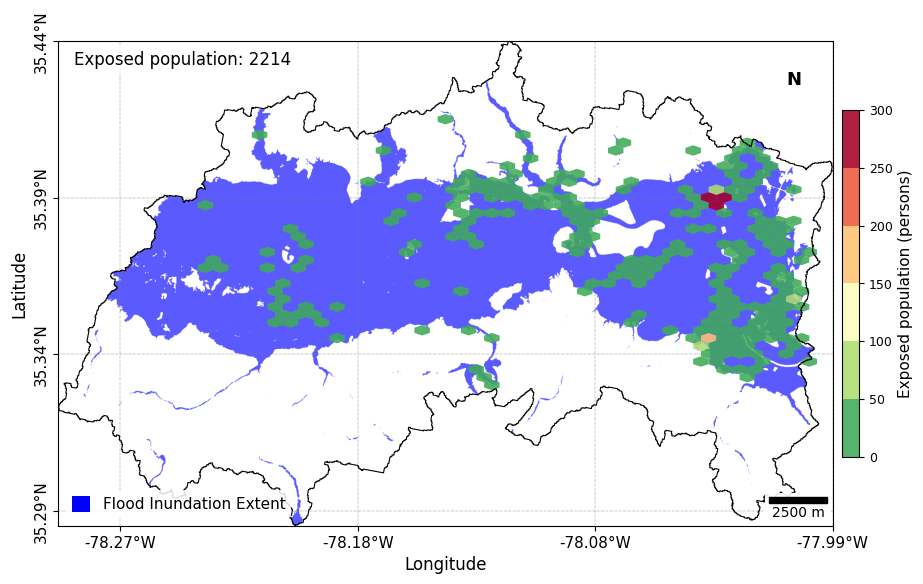

Processing population exposure for: SM_results/HUC03020201/SMprediction_hand_NWM_20161014150000_03020201_inundation_clipped.tif
Total exposed population:
------------------------
343.2


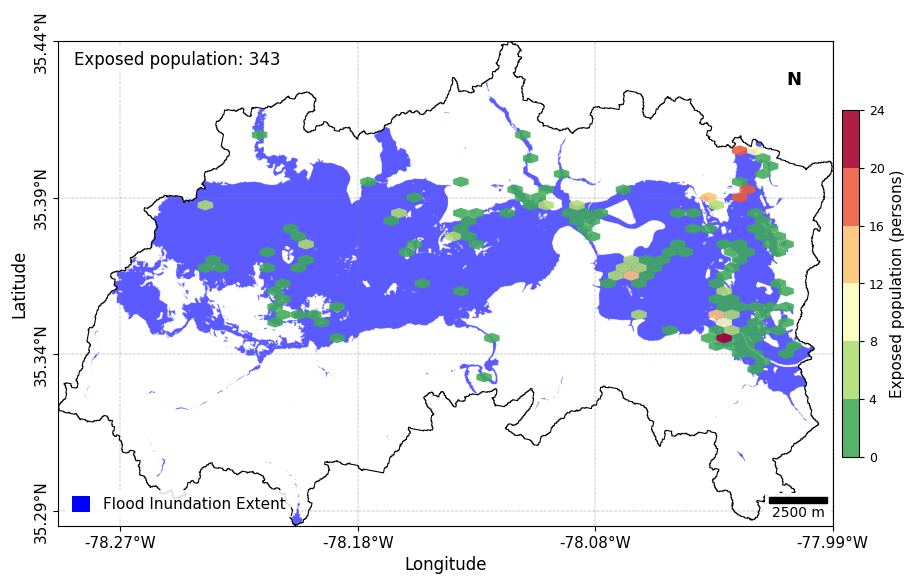

Population exposure estimation completed.
Querying https://services.arcgis.com/P3ePLMYs2RVChkJx/arcgis/rest/services/MSBFP2/FeatureServer/0...
Clipping 17203 features to boundary...

SUCCESS: Saved 10816 buildings to:
  SM_results/HUC03020201/BuildingFootprint/building_footprints.gpkg
Total flooded buildings: 
------
 975


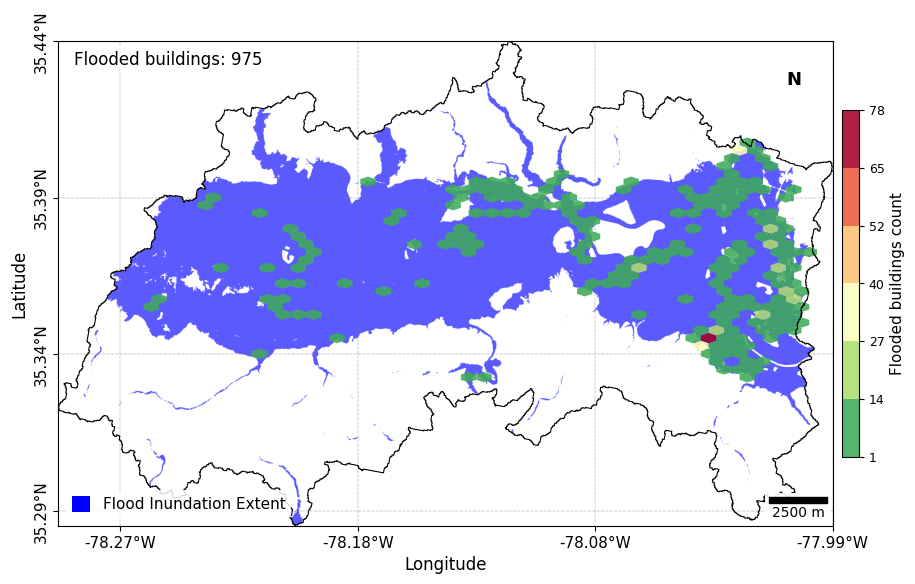

Total flooded buildings: 
------
 295


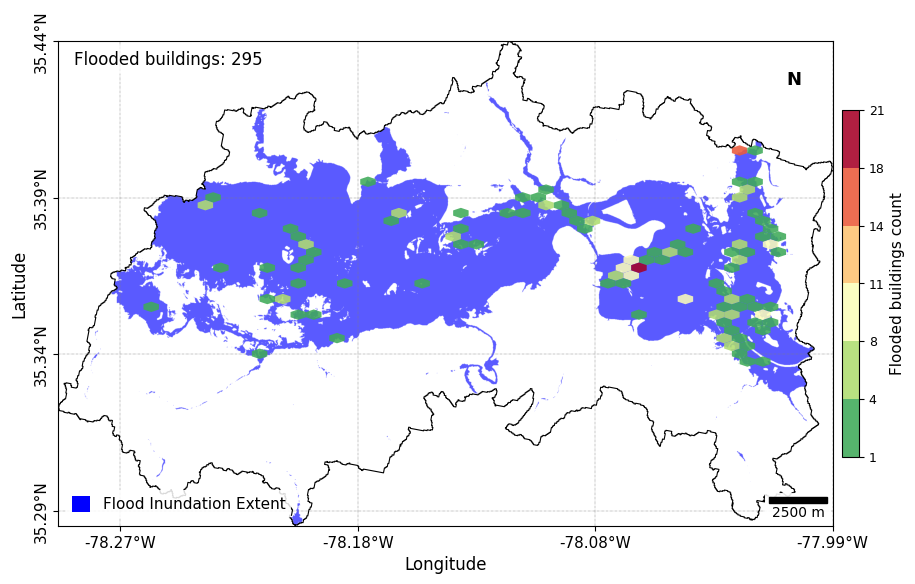

Building exposure estimation completed.


In [ ]:
#Get the population exposure map
fm.getpopulation_exposure(huc_id, boundary = test_boundary, pop_raster=None)
print("Population exposure estimation completed.")

#Get the building exposure map
fm.getbuilding_exposure(huc_id, boundary = test_boundary)
print("Building exposure estimation completed.")

### Side by Side comparision

In [ ]:
# @title
import numpy as np
import rasterio
import base64
from io import BytesIO
from PIL import Image
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
from rasterio.crs import CRS
from ipyleaflet import Map, ImageOverlay, LayersControl, basemaps
from ipywidgets import Layout, FloatSlider, VBox, HBox

def _get_overlay(path, rgb, name, assumed_crs="EPSG:5070", max_size=1200):
    with rasterio.open(path) as src:
        # Resolve CRS
        src_crs = src.crs if src.crs else CRS.from_user_input(assumed_crs)
        dst_crs = CRS.from_epsg(4326)

        # Calculate transform and downscale
        tr, w, h = calculate_default_transform(src_crs, dst_crs, src.width, src.height, *src.bounds)
        scale = max(w, h) / max_size
        if scale > 1:
            w, h = int(w / scale), int(h / scale)
            tr, w, h = calculate_default_transform(src_crs, dst_crs, src.width, src.height, *src.bounds, dst_width=w, dst_height=h)

        # Reproject
        dst = np.full((h, w), np.nan, dtype="float32")
        reproject(rasterio.band(src, 1), dst, src_transform=src.transform, src_crs=src_crs,
                  dst_transform=tr, dst_crs=dst_crs, dst_nodata=np.nan, resampling=Resampling.nearest)

    # Correct unpacking: west, south, east, north
    west, south, east, north = array_bounds(h, w, tr)

    # Generate PNG
    mask = np.isfinite(dst) & (dst > 0)
    rgba = np.zeros((*mask.shape, 4), dtype=np.uint8)
    rgba[mask] = [*rgb, 180]

    buf = BytesIO()
    Image.fromarray(rgba, mode="RGBA").save(buf, format="PNG")
    url = "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()
    return ImageOverlay(url=url, bounds=((south, west), (north, east)), name=name), (south, west, north, east)

def compare_rasters(path_a, path_b, name_a="HAND", name_b="Surrogate"):
    lyr_a, b_a = _get_overlay(path_a, (0, 90, 255), name_a)
    lyr_b, b_b = _get_overlay(path_b, (220, 30, 30), name_b)

    # Calculate global bounds
    s, w = min(b_a[0], b_b[0]), min(b_a[1], b_b[1])
    n, e = max(b_a[2], b_b[2]), max(b_a[3], b_b[3])

    m = Map(basemap=basemaps.CartoDB.Positron, center=((s + n) / 2, (w + e) / 2), zoom=12, layout=Layout(height='600px'))
    m.add(lyr_a); m.add(lyr_b); m.add(LayersControl())
    m.fit_bounds([[s, w], [n, e]])

    # Opacity Sliders
    sa = FloatSlider(value=0.7, min=0, max=1, step=0.05, description=name_a)
    sb = FloatSlider(value=0.7, min=0, max=1, step=0.05, description=name_b)
    sa.observe(lambda c: setattr(lyr_a, 'opacity', c['new']), 'value')
    sb.observe(lambda c: setattr(lyr_b, 'opacity', c['new']), 'value')
    lyr_a.opacity = lyr_b.opacity = 0.7

    return VBox([m, HBox([sa, sb])])

In [ ]:
# Raster path
hand_path = "/content/HUC03020201_forcings/hand_NWM_20161014150000_03020201_inundation_clipped.tif"   #HAND
sm_path = "/content/SM_results/HUC03020201/SMprediction_hand_NWM_20161014150000_03020201_inundation_clipped.tif"      #SM

compare_rasters(hand_path, sm_path)